
# レジームスイッチングと多変量正規分布を用いた市場動態のモデリング (v2)

このノートブックでは、S&P 500 (SPX) と米国10年国債利回り (DGS10) のデータに対し、**隠れマルコフモデル的なアプローチ（GMMによるレジーム分類＋推移確率行列）**と**レジーム別の多変量正規分布（静的相関）**を組み合わせた分析パイプラインを解説します。

## 全体のパイプライン概要
1. **特徴量エンジニアリング**: SPXとDGS10の標準偏差、相関係数を計算し、市場の「状態」を捉えやすくする。（※平均値は使用しません）
2. **GMMによるクラスタリング**: 特徴量を元に、市場を4つの状態（レジーム）に分類する。
3. **推移確率行列の計算**: 状態間の遷移確率を経験的に計算する。
4. **状態ごとのARIMAモデリング（期待値の計算）**: 各状態でARIMAXモデルを推定し、条件付き期待値を算出する。
5. **レジーム別共分散行列の計算とシミュレーション**: 各レジームのARIMA予測残差から分散共分散行列（相関）を計算し、多変量正規分布からショックを発生させてシミュレーションを行う。


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
# from statsmodels.tsa.arima.model import ARIMA  # Removed: VARMAX used exclusively
from statsmodels.tsa.statespace.varmax import VARMAX
import warnings
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')



## 1. データの読み込みと特徴量エンジニアリング

### 理論
金融市場は常に同じ法則で動いているわけではなく、「ボラティリティが高い時期」「金利と株価が逆相関になる時期」など、マクロ的な環境（レジーム）が変化します。
この環境変化を捉えるため、単純な価格の変動だけでなく、「20日（約1ヶ月）の標準偏差、および相関」という**ローリング特徴量**を作成します。
さらに、市場の方向性（トレンド）を捉えるため、「20日間の変化分」を特徴量として加えます。
- SPXの20日変化分：20日間の累積リターン（積）
- DGS10の20日変化分：20日間の変動幅（和）

これにより、瞬間的なノイズではなく、一定期間のボラティリティの強さ、資産間の関係性、そして相場のトレンドを総合的に元に状態を分類できるようになります。


In [3]:
df = pd.read_csv('/home/u00118/train_sp500_us10y.csv')
if 'Unnamed: 0' in df.columns:
    df['Date'] = pd.to_datetime(df['Unnamed: 0'])
    df.set_index('Date', inplace=True)
    df.drop(columns=['Unnamed: 0'], inplace=True)

# ローリング特徴量の作成 (20日 = 約1ヶ月)
window = 20
df['sp500_roll_std'] = df['sp500'].rolling(window=window).std()
df['DGS10_roll_std'] = df['DGS10'].rolling(window=window).std()
df['corr'] = df['sp500'].rolling(window=window).corr(df['DGS10'])

# 20日間の変化分（トレンド）の追加
df['sp500_roll_ret20'] = (1 + df['sp500']).rolling(window=window).apply(np.prod, raw=True) - 1
df['DGS10_roll_sum20'] = df['DGS10'].rolling(window=window).sum()

# もう一方の変数の過去1日分のデータ（外生変数用）
df['DGS10_lag1'] = df['DGS10'].shift(1)
df['sp500_lag1'] = df['sp500'].shift(1)

# 欠損値の削除
df_features = df.dropna().copy()
print(f"有効なデータ件数: {len(df_features)}件")

# GMMクラスタリング用の特徴量（5次元）
features = df_features[['sp500_roll_std', 'DGS10_roll_std', 'corr', 'sp500_roll_ret20', 'DGS10_roll_sum20']]


有効なデータ件数: 14715件



## 2. GMMを用いたN個の状態（レジーム）へのクラスタリング

### 理論と計算手法（数式）
GMM（Gaussian Mixture Model: 混合ガウスモデル）は、データが複数の正規分布の集まり（混合分布）から生成されていると仮定し、それぞれのデータがどの分布から生成されたか（どの状態に属するか）を確率的に推定する手法です。ここでは変数を設定し、市場を任意の数（`N_REGIMES`）のレジームに分類できるようにしています。

**1. モデルの確率密度関数**
特徴量ベクトル $x$ が与えられたときの全体の確率分布 $P(x)$ は、各レジームの正規分布の線形結合として表されます。
$$
P(x) = \sum_{k=1}^K \pi_k \mathcal{N}(x \mid \mu_k, \Sigma_k)
$$

**2. EMアルゴリズムによるパラメータ推定**
未知のパラメータ $\theta = \{\pi_k, \mu_k, \Sigma_k\}$ は、尤度が最大になるように **EMアルゴリズム** によって反復計算で推定されます。

**3. レジームの判定**
EMアルゴリズムが収束した後、各時点 $t$ における市場のレジーム $S_t$ は、最も事後確率が高い分布として割り当てられます（ハードクラスタリング）。
$$
S_t = \arg\max_k \gamma(z_{tk})
$$
これにより、「平穏な相場」「荒れ相場」などが自動的にグループ化されます。


In [4]:
# レジームの数を指定（ここを変更するだけで全体に反映されます）
N_REGIMES = 14

gmm = GaussianMixture(n_components=N_REGIMES, random_state=42, n_init=10)
df_features['Regime'] = gmm.fit_predict(features)

print("各レジームのデータ件数:")
print(df_features['Regime'].value_counts().sort_index())

# 状態の可視化 (Plotly)
fig = go.Figure()

# S&P 500 Return
fig.add_trace(go.Scatter(
    x=df_features.index, y=df_features['sp500'],
    mode='lines',
    line=dict(color='black', width=1),
    opacity=0.3,
    name='S&P 500 Return'
))

# 各レジームの散布図
colors = px.colors.qualitative.Plotly
for i in range(N_REGIMES):
    mask = df_features['Regime'] == i
    fig.add_trace(go.Scatter(
        x=df_features.index[mask], y=df_features['sp500'][mask],
        mode='markers',
        marker=dict(color=colors[i % len(colors)], size=4),
        name=f'Regime {i}'
    ))

fig.update_layout(
    title=f'S&P 500 Returns by GMM Clustered Regime (N={N_REGIMES})',
    xaxis_title='Date',
    yaxis_title='Return',
    height=500,
    legend_title='Legend (Click to toggle)'
)
fig.show()


各レジームのデータ件数:
Regime
0      931
1      450
2     2123
3      493
4     1653
5      654
6      807
7     2958
8      678
9      260
10     149
11     776
12    1620
13    1163
Name: count, dtype: int64



## 3. 状態遷移確率行列の計算

### 理論
市場のレジームは、ランダムに切り替わるわけではありません。「荒れ相場」の次の日は「荒れ相場」になりやすいといった**持続性（マルコフ性）**があります。
推移確率行列（Transition Matrix）は、「現在の状態が $i$ のとき、次の日に状態が $j$ になる確率 $P(S_{t+1}=j | S_t=i)$」を行列にしたものです。
対角成分（[0,0]や[1,1]など）が大きいほど、その状態が持続しやすいことを意味します。


In [5]:
transition_matrix = np.zeros((N_REGIMES, N_REGIMES))
regimes = df_features['Regime'].values
for t in range(1, len(regimes)):
    from_state = regimes[t-1]
    to_state = regimes[t]
    transition_matrix[from_state, to_state] += 1

# 行ごとに正規化して確率に変換
transition_matrix = transition_matrix / transition_matrix.sum(axis=1, keepdims=True)

print("【推移確率行列 (Transition Matrix)】")
for i in range(N_REGIMES):
    probs_str = ", ".join([f"[{j}]:{transition_matrix[i,j]:.3f}" for j in range(N_REGIMES)])
    print(f"状態 {i} からの遷移確率: {probs_str}")


【推移確率行列 (Transition Matrix)】
状態 0 からの遷移確率: [0]:0.823, [1]:0.000, [2]:0.032, [3]:0.013, [4]:0.039, [5]:0.002, [6]:0.033, [7]:0.013, [8]:0.027, [9]:0.003, [10]:0.000, [11]:0.000, [12]:0.000, [13]:0.015
状態 1 からの遷移確率: [0]:0.000, [1]:0.896, [2]:0.007, [3]:0.000, [4]:0.000, [5]:0.031, [6]:0.002, [7]:0.000, [8]:0.000, [9]:0.002, [10]:0.002, [11]:0.027, [12]:0.027, [13]:0.007
状態 2 からの遷移確率: [0]:0.008, [1]:0.005, [2]:0.826, [3]:0.003, [4]:0.001, [5]:0.008, [6]:0.022, [7]:0.039, [8]:0.000, [9]:0.000, [10]:0.000, [11]:0.007, [12]:0.043, [13]:0.039
状態 3 からの遷移確率: [0]:0.034, [1]:0.000, [2]:0.008, [3]:0.858, [4]:0.000, [5]:0.000, [6]:0.037, [7]:0.000, [8]:0.041, [9]:0.002, [10]:0.010, [11]:0.008, [12]:0.000, [13]:0.002
状態 4 からの遷移確率: [0]:0.024, [1]:0.000, [2]:0.001, [3]:0.000, [4]:0.901, [5]:0.000, [6]:0.010, [7]:0.041, [8]:0.023, [9]:0.000, [10]:0.000, [11]:0.000, [12]:0.000, [13]:0.000
状態 5 からの遷移確率: [0]:0.005, [1]:0.014, [2]:0.040, [3]:0.000, [4]:0.000, [5]:0.817, [6]:0.000, [7]:0.000, [8]:0.000, [9]


## 4. 状態ごとのVARMAXモデリング（期待値の計算）

### 内部でのカルマンフィルタ（状態空間モデル）の役割と数式表現

本コードで使用している `statsmodels` の `VARMAX` クラスは、内部的にモデルを**線形状態空間モデル（Linear State-Space Model）**として定式化し、**カルマンフィルタ（Kalman Filter）**を用いて最尤推定および期待値の算出を行っています。
# ARIMA modeling removed; VARMAX handles predictions for both series

（$\phi$ はAR係数、$\theta$ はMA係数）

**カルマンフィルタによる予測と更新のアルゴリズム**
与えられたデータから尤度を計算し、最適な予測を得るために、以下の漸化式を各時点 $t$ で反復します。
* **予測ステップ (Prediction)**:
  * 状態の事前推定: $a_{t|t-1} = T a_{t-1|t-1}$
  * 誤差共分散の事前推定: $P_{t|t-1} = T P_{t-1|t-1} T^\top + R Q R^\top$
* **更新ステップ (Update)**:
  * 観測の予測誤差 (イノベーション): $v_t = y_t - Z a_{t|t-1} - x_t^\top \beta$
  * 予測誤差の分散: $F_t = Z P_{t|t-1} Z^\top + H$
  * カルマンゲイン (修正の重み): $K_t = P_{t|t-1} Z^\top F_t^{-1}$
  * 状態の事後推定: $a_{t|t} = a_{t|t-1} + K_t v_t$
  * 誤差共分散の事後推定: $P_{t|t} = P_{t|t-1} - K_t Z P_{t|t-1}$

**欠損データ（非連続なレジーム）に対するカルマンフィルタの挙動**
本分析ではレジームごとにデータを分割しているため、対象外のレジームの期間は `NaN`（欠損値）となります。カルマンフィルタはこのようなトビトビのデータに対して以下のように振る舞います。
* **データが欠損している時点 $t$**:
  観測値 $y_t$ が存在しないため、更新ステップ（Update）はスキップされます（事実上カルマンゲイン $K_t = 0$）。
  しかし、予測ステップ（Prediction）は継続して行われるため、事後推定値は更新されず（$a_{t|t} = a_{t|t-1}$）、次の時点への予測状態は以下のように前進し続けます。
  $$ a_{t+1|t} = T a_{t|t} = T a_{t|t-1} $$
  $$ P_{t+1|t} = T P_{t|t} T^\top + R Q R^\top = T P_{t|t-1} T^\top + R Q R^\top $$
  これにより、カレンダー通りの正しい時間関係（ラグ）を維持したまま、見えない期間の内部状態（ARMAプロセスの見えないノイズ）を推定し続けることができます。

`model.fit()` は、このカルマンフィルタから得られる予測誤差 $v_t$ とその分散 $F_t$ を用いて対数尤度を計算し、尤度が最大になるようにパラメータ（$\phi, \theta, \beta$ 等）を最適化しています。


In [6]:
# モデルの保存用辞書


models_varmax = {}
df_features['sp500_pred'] = np.nan
df_features['DGS10_pred'] = np.nan

for i in range(N_REGIMES):
    print(f"\n--- レジーム {i} のモデルフィッティング ---")
    mask = df_features['Regime'] == i
    
    # VARMAX モデル (exog: DGS10_lag1, sp500_lag1) with order (p=2, q=1)
    # Endogenous variables: sp500 and DGS10
    endog = df_features[['sp500', 'DGS10']].copy()
    endog[~mask] = np.nan
    exog = df_features[['DGS10_lag1', 'sp500_lag1']]
    try:
        model = VARMAX(endog=endog, exog=exog, order=(2, 1))
        res = model.fit(disp=False)
        models_varmax[i] = res
        preds = res.predict()
        df_features.loc[mask, 'sp500_pred'] = preds.loc[mask, 'sp500']
        df_features.loc[mask, 'DGS10_pred'] = preds.loc[mask, 'DGS10']
        print(f"【VARMAX 推定パラメータ】\n{res.params}")
    except Exception as e:
        print(e)

# 残差（予測誤差）を全期間連続データとして計算
df_features['resid_sp500'] = df_features['sp500'] - df_features['sp500_pred']
df_features['resid_dgs'] = df_features['DGS10'] - df_features['DGS10_pred']
df_features['resid_sp500'].fillna(0, inplace=True)
df_features['resid_dgs'].fillna(0, inplace=True)



--- レジーム 0 のモデルフィッティング ---
【VARMAX 推定パラメータ】
intercept.sp500         -0.000012
intercept.DGS10          0.000824
L1.sp500.sp500           0.694621
L1.DGS10.sp500          -0.003791
L2.sp500.sp500           0.282371
L2.DGS10.sp500           0.005653
L1.sp500.DGS10           0.159460
L1.DGS10.DGS10           0.711178
L2.sp500.DGS10          -0.096825
L2.DGS10.DGS10           0.224899
L1.e(sp500).sp500       -0.318203
L1.e(DGS10).sp500       -0.021847
L1.e(sp500).DGS10       -0.176532
L1.e(DGS10).DGS10       -0.405394
beta.DGS10_lag1.sp500    0.013997
beta.sp500_lag1.sp500   -0.181898
beta.DGS10_lag1.DGS10   -0.319337
beta.sp500_lag1.DGS10   -0.009297
sqrt.var.sp500          -0.012891
sqrt.cov.sp500.DGS10    -0.013610
sqrt.var.DGS10          -0.051939
dtype: float64

--- レジーム 1 のモデルフィッティング ---
【VARMAX 推定パラメータ】
intercept.sp500         -0.001317
intercept.DGS10          0.004276
L1.sp500.sp500           0.710842
L1.DGS10.sp500          -0.002975
L2.sp500.sp500           0.441578
L2.DGS10.sp

Date
1966-01-28    0.079923
1966-01-31    0.048836
1966-02-01   -0.007295
1966-02-02   -0.006777
1966-02-03   -0.001745
                ...   
2025-09-26    0.008235
2025-09-29   -0.057596
2025-09-30   -0.000853
2025-10-01   -0.024756
2025-10-02   -0.020746
Name: resid_dgs, Length: 14715, dtype: float64


### レジームごとの予測誤差（残差）の分布比較
各レジームにおけるARIMAモデルの予測誤差（実際の値 - 予測値）の分布を、**度数分布多角形（Frequency Polygon）**で比較します。
横軸に予測誤差、縦軸に密度（Density）を配置することで、レジームのばらつき（ボラティリティの大きさ）や分布の偏りを、凡例のクリックで直感的に表示・非表示を切り替えながら比較できます。


In [7]:
# レジームごとの分布可視化 (Plotly)
fig = make_subplots(rows=1, cols=2, subplot_titles=("SPX Prediction Error Distribution", "DGS10 Prediction Error Distribution"))
colors = px.colors.qualitative.Plotly

# ビンの幅を全体で統一して計算
spx_min, spx_max = df_features['resid_sp500'].min(), df_features['resid_sp500'].max()
dgs_min, dgs_max = df_features['resid_dgs'].min(), df_features['resid_dgs'].max()
spx_bins = np.linspace(spx_min, spx_max, 50)
dgs_bins = np.linspace(dgs_min, dgs_max, 50)
spx_bin_centers = (spx_bins[:-1] + spx_bins[1:]) / 2
dgs_bin_centers = (dgs_bins[:-1] + dgs_bins[1:]) / 2

for i in range(N_REGIMES):
    mask = df_features['Regime'] == i
    data_spx = df_features.loc[mask, 'resid_sp500'].dropna()
    data_dgs = df_features.loc[mask, 'resid_dgs'].dropna()
    
    # SPX Frequency Polygon
    if len(data_spx) > 1:
        hist_spx, _ = np.histogram(data_spx, bins=spx_bins, density=True)
        fig.add_trace(go.Scatter(
            x=spx_bin_centers, y=hist_spx, mode='lines',
            name=f'Regime {i}', line=dict(color=colors[i % len(colors)], width=2),
            legendgroup=f'Regime {i}', showlegend=True
        ), row=1, col=1)
    
    # DGS10 Frequency Polygon
    if len(data_dgs) > 1:
        hist_dgs, _ = np.histogram(data_dgs, bins=dgs_bins, density=True)
        fig.add_trace(go.Scatter(
            x=dgs_bin_centers, y=hist_dgs, mode='lines',
            name=f'Regime {i}', line=dict(color=colors[i % len(colors)], width=2),
            legendgroup=f'Regime {i}', showlegend=False
        ), row=1, col=2)

fig.update_layout(
    height=500,
    legend_title='Legend (Click to toggle)'
)
fig.update_xaxes(title_text="Prediction Error", row=1, col=1)
fig.update_yaxes(title_text="Density", row=1, col=1)
fig.update_xaxes(title_text="Prediction Error", row=1, col=2)
fig.update_yaxes(title_text="Density", row=1, col=2)
fig.show()



## 5. レジーム別共分散行列の計算とシミュレーション生成

### 理論: レジームごとの多変量正規分布によるシミュレーション

レジームごとに「予測誤差の分散共分散行列（固定相関）」を計算し、各時点での現在のレジームに対応する多変量正規分布からショックをサンプリングします。

$$
\begin{pmatrix} y_{sp, t} \\ y_{dgs, t} \end{pmatrix}_{sim} = \begin{pmatrix} \hat{y}_{sp, t} \\ \hat{y}_{dgs, t} \end{pmatrix} + \epsilon_t
$$
$$
\epsilon_t \sim \mathcal{N}(0, \Sigma_{S_t})
$$
ここで $\Sigma_{S_t}$ は、時点 $t$ でのレジーム $S_t$ におけるSPXとDGS10の残差の共分散行列です。これにより、平穏な時期と荒れ相場の違いは表現しつつ、極端な相関のスパイクを持たない安定したシミュレーションデータが生成されます。



【Regime 0 共分散行列】
[[0.00022451 0.00021238]
 [0.00021238 0.00357818]]
相関係数: 0.2370

【Regime 1 共分散行列】
[[ 0.00017782 -0.00081087]
 [-0.00081087  0.01136826]]
相関係数: -0.5703

【Regime 2 共分散行列】
[[ 6.68134272e-05 -1.48341178e-04]
 [-1.48341178e-04  3.71302993e-03]]
相関係数: -0.2978

【Regime 3 共分散行列】
[[0.00048506 0.00053103]
 [0.00053103 0.00841688]]
相関係数: 0.2628

【Regime 4 共分散行列】
[[8.23400148e-05 2.64914340e-04]
 [2.64914340e-04 2.67547519e-03]]
相関係数: 0.5644

【Regime 5 共分散行列】
[[ 0.00016292 -0.00141284]
 [-0.00141284  0.02805187]]
相関係数: -0.6609

【Regime 6 共分散行列】
[[ 1.95358324e-04 -4.71595669e-05]
 [-4.71595669e-05  3.99650605e-03]]
相関係数: -0.0534

【Regime 7 共分散行列】
[[4.08449211e-05 1.28007291e-05]
 [1.28007291e-05 1.25266805e-03]]
相関係数: 0.0566

【Regime 8 共分散行列】
[[0.00029161 0.00078529]
 [0.00078529 0.00478898]]
相関係数: 0.6645

【Regime 9 共分散行列】
[[ 0.00047893 -0.00117738]
 [-0.00117738  0.02767149]]
相関係数: -0.3234

【Regime 10 共分散行列】
[[0.00217524 0.00021457]
 [0.00021457 0.02322353]]
相関係数: 0.0302

【Regime

,Regime,sp500,sp500_pred,sp500_simulated,DGS10,DGS10_pred,DGS10_simulated
Date,,,,,,,
2025-09-19,12,0.004885,0.000363,-0.007443,0.03,0.008292,0.084357
2025-09-22,7,0.004410,-0.003034,-0.014692,0.01,0.009099,-0.000385
2025-09-23,7,-0.005502,0.000913,0.001082,-0.03,0.010298,0.009959
2025-09-24,7,-0.002847,0.001581,-0.001912,0.04,0.006412,-0.000219
2025-09-25,7,-0.005009,-0.001478,0.003295,0.02,-0.010046,0.017126
2025-09-26,7,0.005902,-0.000437,0.001775,0.02,0.011765,0.024323
2025-09-29,7,0.002636,-0.001387,-0.006502,-0.05,0.007596,-0.052015
2025-09-30,7,0.004091,0.001744,0.005035,0.01,0.010853,-0.054740
2025-10-01,7,0.003400,0.000718,0.008462,-0.04,-0.015244,-0.030245


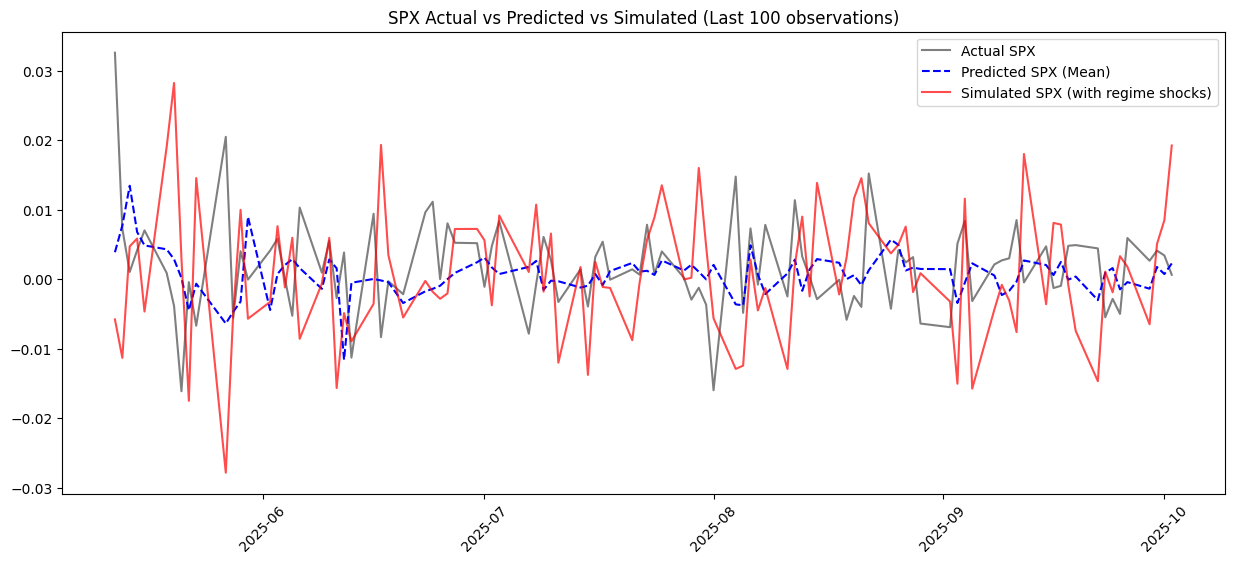

In [8]:
# レジームごとの共分散行列を計算
regime_cov_matrices = {}

for i in range(N_REGIMES):
    mask = df_features['Regime'] == i
    res_sp = df_features.loc[mask, 'resid_sp500'].values
    res_dgs = df_features.loc[mask, 'resid_dgs'].values
    
    # NaNを除外して計算
    valid_mask = ~np.isnan(res_sp) & ~np.isnan(res_dgs)
    if valid_mask.sum() > 1:
        cov_matrix = np.cov(res_sp[valid_mask], res_dgs[valid_mask])
        regime_cov_matrices[i] = cov_matrix
        print(f"\n【Regime {i} 共分散行列】")
        print(cov_matrix)
        # 相関係数も表示
        corr = cov_matrix[0, 1] / np.sqrt(cov_matrix[0, 0] * cov_matrix[1, 1])
        print(f"相関係数: {corr:.4f}")
    else:
        # データが足りない場合は単位行列を使用
        regime_cov_matrices[i] = np.eye(2) * 1e-6

# シミュレーションの実行
df_features['sp500_simulated'] = np.nan
df_features['DGS10_simulated'] = np.nan

shocks_sp = np.zeros(len(df_features))
shocks_dgs = np.zeros(len(df_features))

regimes = df_features['Regime'].values

np.random.seed(46) # 再現性のためのシード

for t in range(len(df_features)):
    sim_regime = regimes[t]
    cov_matrix = regime_cov_matrices[sim_regime]
    
    # 2変量正規分布からショックをサンプリング
    shock = np.random.multivariate_normal([0, 0], cov_matrix)
    
    shocks_sp[t] = shock[0]
    shocks_dgs[t] = shock[1]

# ARIMAの期待値にショックを足す
df_features['sp500_simulated'] = df_features['sp500_pred'] + shocks_sp
df_features['DGS10_simulated'] = df_features['DGS10_pred'] + shocks_dgs

print("\nレジーム別の固定相関（共分散行列）を反映したシミュレーションデータを生成しました！")

round_cols = ['sp500_pred', 'sp500_simulated', 'DGS10_pred', 'DGS10_simulated']
df_features[round_cols] = df_features[round_cols].round(6)

output_df = df_features[['Regime', 'sp500', 'sp500_pred', 'sp500_simulated', 'DGS10', 'DGS10_pred', 'DGS10_simulated']]
print("【直近10日間の実際の値と予測値・シミュレーション値】")
display(output_df.tail(10))

# 実際の値と予測値・シミュレーション値のプロット
plt.figure(figsize=(15, 6))
plt.plot(output_df.index[-100:], output_df['sp500'][-100:], label='Actual SPX', color='black', alpha=0.5)
plt.plot(output_df.index[-100:], output_df['sp500_pred'][-100:], label='Predicted SPX (Mean)', color='blue', linestyle='--')
plt.plot(output_df.index[-100:], output_df['sp500_simulated'][-100:], label='Simulated SPX (with regime shocks)', color='red', alpha=0.7)
plt.title('SPX Actual vs Predicted vs Simulated (Last 100 observations)')
plt.xticks(rotation=45)
plt.legend()
plt.show()



## 6. 全期間での累積リターンの比較

初期値を $1$ として、実際のSPXリターンと、期待値のみを用いた予測リターン、ランダムショックを加えたシミュレーションリターンを累積（複利計算）して比較します。
※モデルが出力する期待値（`sp500_pred`）はボラティリティを持たないため、複利計算の仕様上（ボラティリティ・ドラッグの欠如により）非現実的な軌道を描いてしまう傾向がありますが、参考として表示しています。


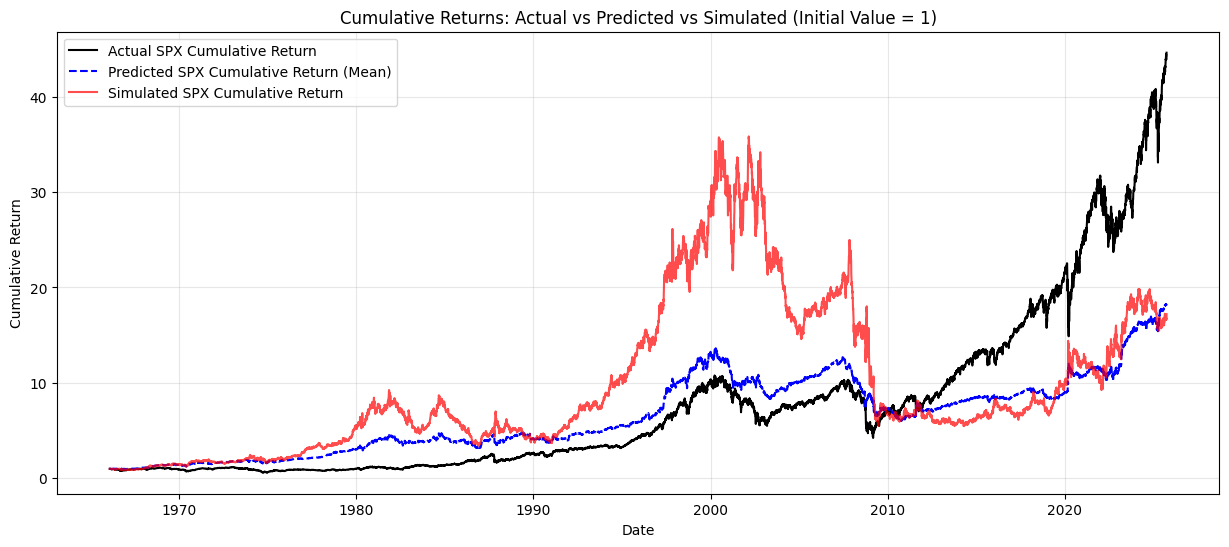

In [9]:
# 欠損値（NaN）を0で埋めてから累積積（cumprod）を計算
df_features['cum_sp500'] = (1 + df_features['sp500'].fillna(0)).cumprod()
df_features['cum_sp500_pred'] = (1 + df_features['sp500_pred'].fillna(0)).cumprod()
df_features['cum_sp500_sim'] = (1 + df_features['sp500_simulated'].fillna(0)).cumprod()

plt.figure(figsize=(15, 6))
plt.plot(df_features.index, df_features['cum_sp500'], label='Actual SPX Cumulative Return', color='black')
plt.plot(df_features.index, df_features['cum_sp500_pred'], label='Predicted SPX Cumulative Return (Mean)', color='blue', linestyle='--')
plt.plot(df_features.index, df_features['cum_sp500_sim'], label='Simulated SPX Cumulative Return', color='red', alpha=0.7)
plt.title('Cumulative Returns: Actual vs Predicted vs Simulated (Initial Value = 1)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



## 7. 実データとモデル生成データ（予測・シミュレーション）の相関比較

モデルが、S&P 500 と米国10年国債利回り (DGS10) の「2資産間の関係性（相関）」をどれだけ上手く再現できているかを検証します。
今回はレジームごとの固定相関を使用しているため、極端なスパイクのない安定した連動性がシミュレーションに反映されています。


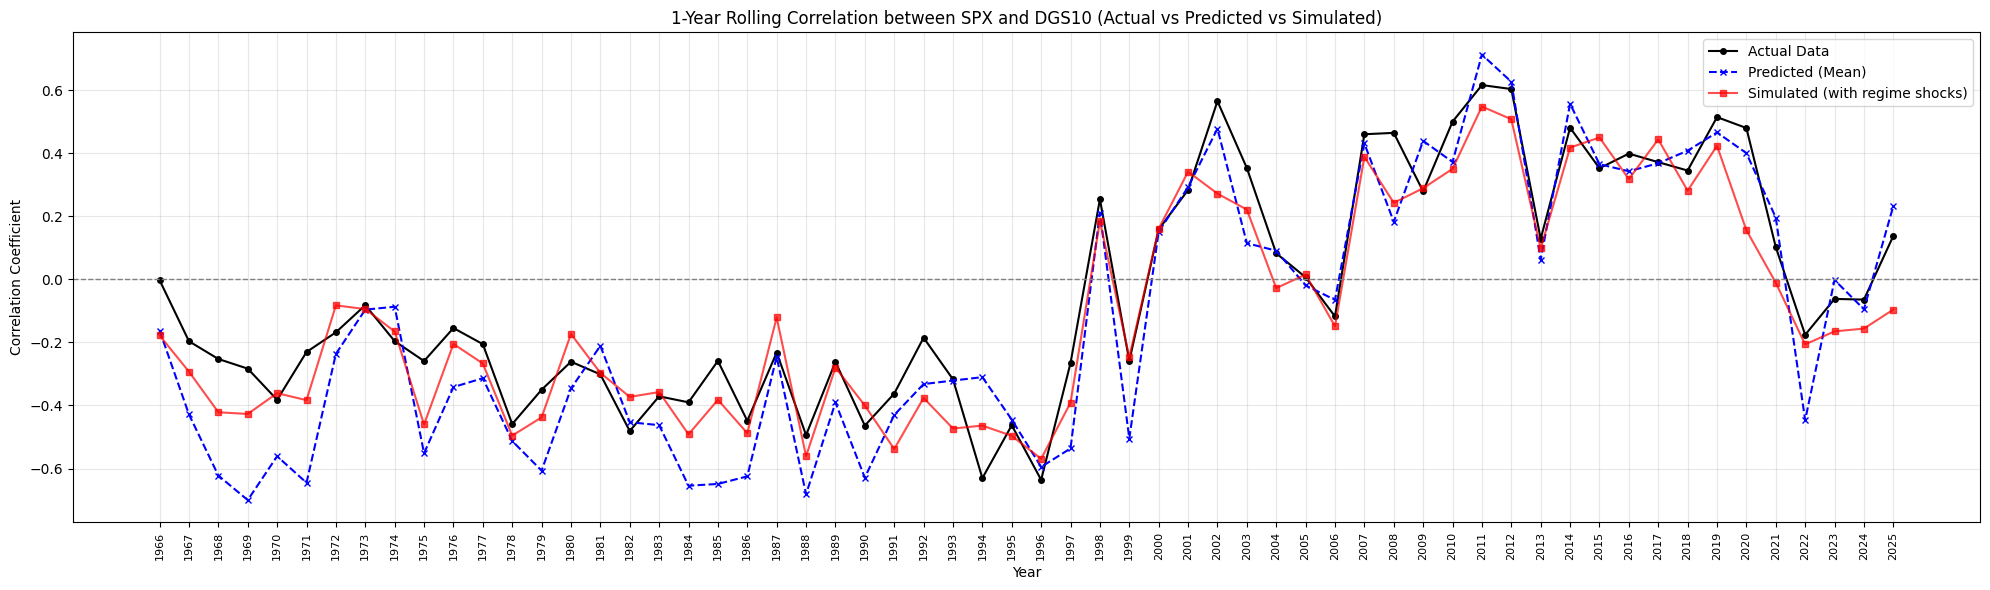


【相関係数のボラティリティ（標準偏差）の比較】


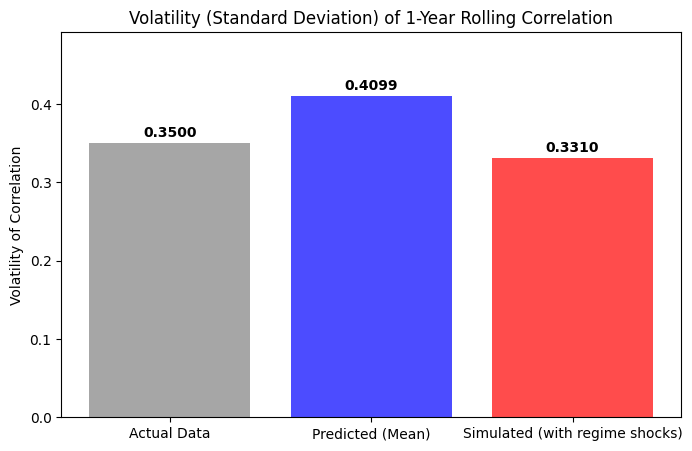

In [10]:
# 1年ごとのビンを作成
df_features['1Y_Label'] = df_features.index.year.astype(str)

# 1年ごとに相関を計算
corr_act = df_features.groupby('1Y_Label').apply(lambda g: g['sp500'].corr(g['DGS10']))
corr_pred = df_features.groupby('1Y_Label').apply(lambda g: g['sp500_pred'].corr(g['DGS10_pred']))
corr_sim = df_features.groupby('1Y_Label').apply(lambda g: g['sp500_simulated'].corr(g['DGS10_simulated']))

corr_1y = pd.DataFrame({'Actual': corr_act, 'Predicted': corr_pred, 'Simulated': corr_sim})

# 折れ線グラフで視覚化
plt.figure(figsize=(20, 6))
plt.plot(corr_1y.index, corr_1y['Actual'], marker='o', label='Actual Data', color='black', linewidth=1.5, markersize=4)
plt.plot(corr_1y.index, corr_1y['Predicted'], marker='x', label='Predicted (Mean)', color='blue', linestyle='--', linewidth=1.5, markersize=4)
plt.plot(corr_1y.index, corr_1y['Simulated'], marker='s', label='Simulated (with regime shocks)', color='red', alpha=0.7, linewidth=1.5, markersize=4)

plt.axhline(0, color='gray', linewidth=1, linestyle='--')
plt.title('1-Year Rolling Correlation between SPX and DGS10 (Actual vs Predicted vs Simulated)')
plt.xlabel('Year')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90, fontsize=8)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 相関係数のボラティリティ比較
vol_act = corr_1y['Actual'].std()
vol_pred = corr_1y['Predicted'].std()
vol_sim = corr_1y['Simulated'].std()

print("\n【相関係数のボラティリティ（標準偏差）の比較】")

# ボラティリティを棒グラフで視覚化
plt.figure(figsize=(8, 5))
labels_vol = ['Actual Data', 'Predicted (Mean)', 'Simulated (with regime shocks)']
values_vol = [vol_act, vol_pred, vol_sim]
colors_vol = ['gray', 'blue', 'red']

plt.bar(labels_vol, values_vol, color=colors_vol, alpha=0.7)
plt.title('Volatility (Standard Deviation) of 1-Year Rolling Correlation')
plt.ylabel('Volatility of Correlation')
for i, v in enumerate(values_vol):
    if pd.notna(v):
        plt.text(i, v + (max([val for val in values_vol if pd.notna(val)] + [0])*0.02), f"{v:.4f}", ha='center', fontweight='bold')
plt.ylim(0, max([val for val in values_vol if pd.notna(val)] + [0.1]) * 1.2)
plt.show()


## 8. 実データとモデル生成データの歪度・尖度の5年ごと比較

モデルが、S&P 500 と米国10年国債利回り (DGS10) の「歪度（Skewness：非対称性）」と「尖度（Kurtosis：テールの厚さ）」の動的な変化をどれだけ再現できているかを検証します。
歪度は分布の左右の非対称性を表し、尖度はテール（極端な値）の太さ（または中心への集中度）を表します。ここでは、統計的な信頼性を担保するため、5年ごとにデータを区切って評価します。

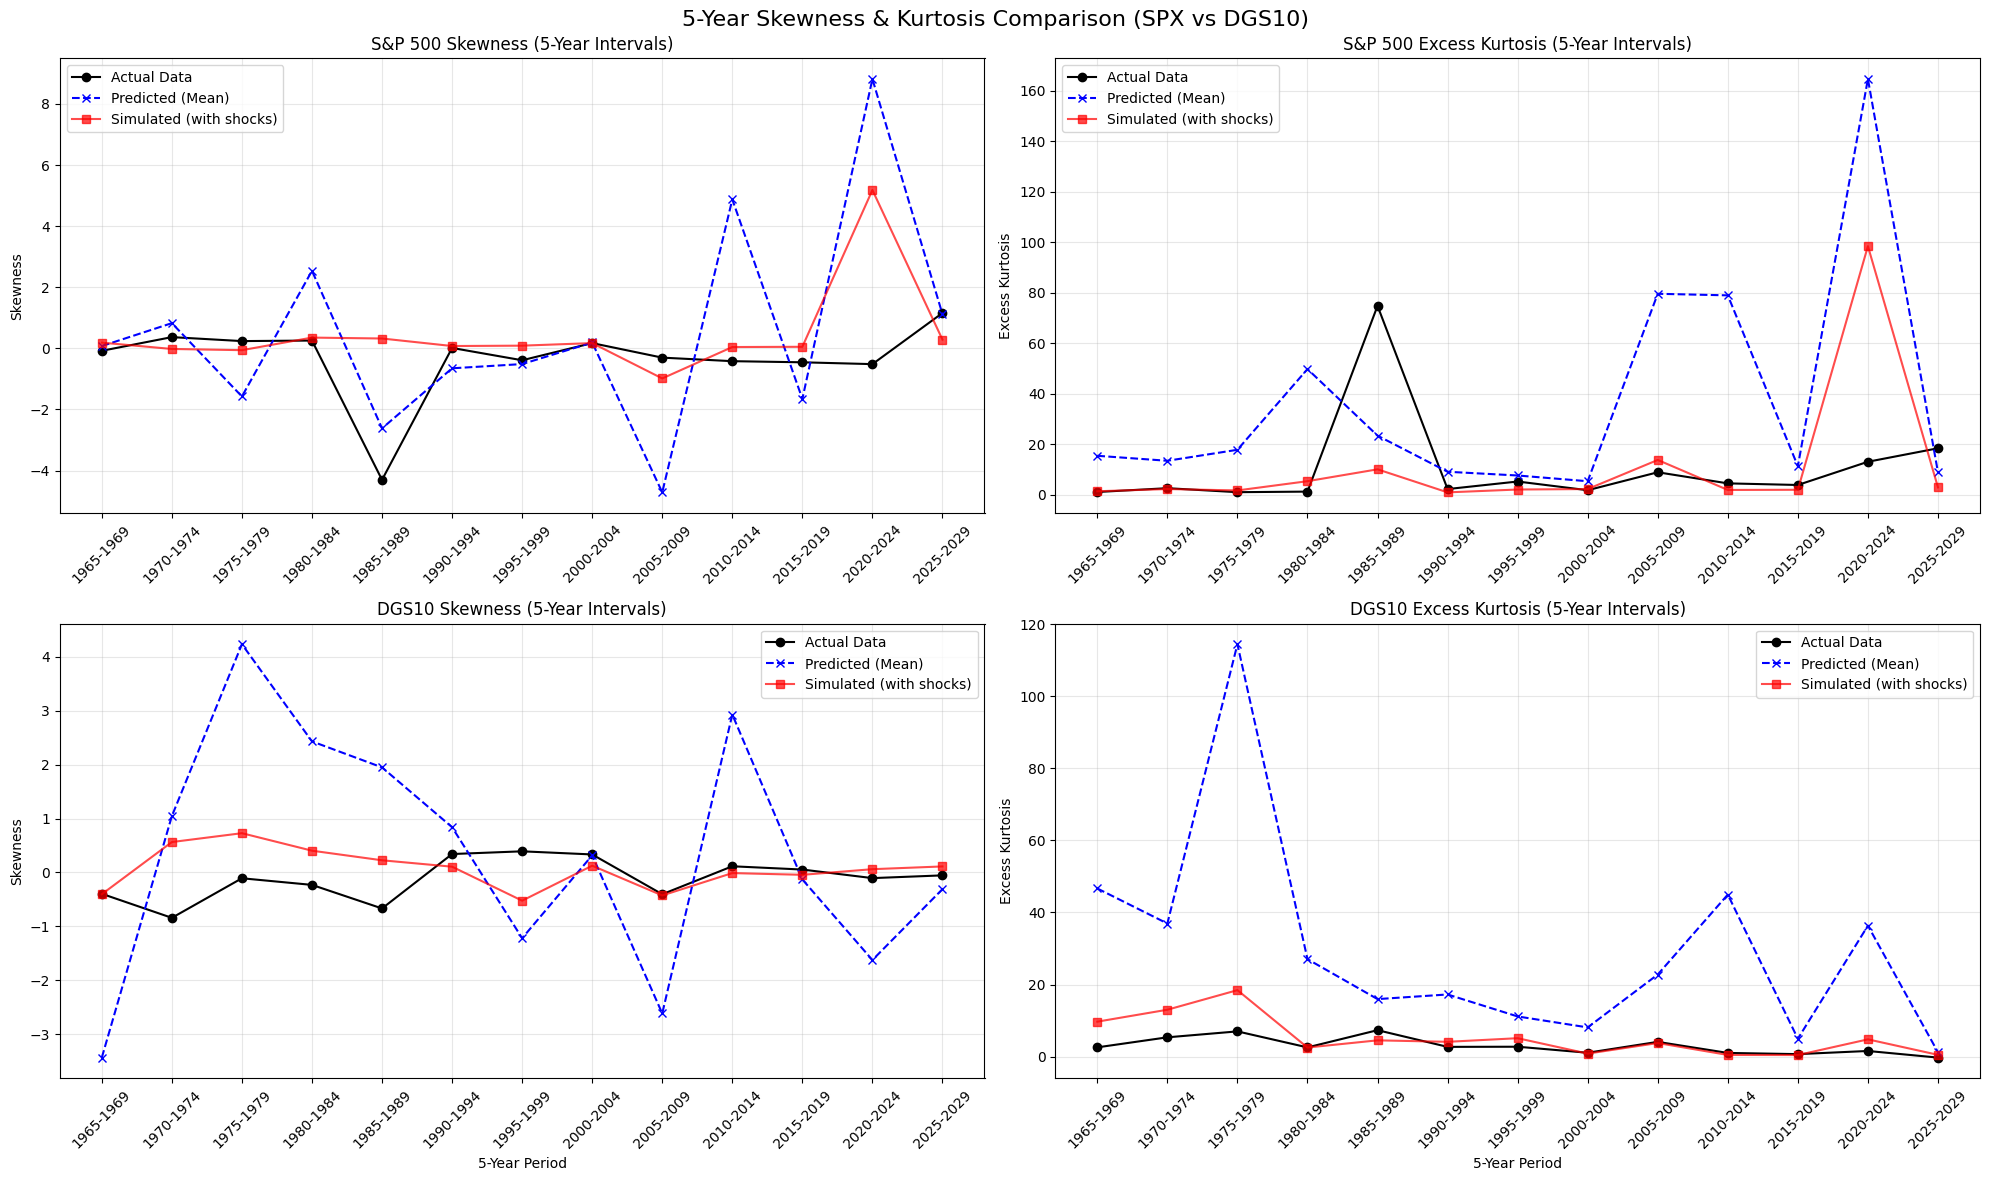

【実データとシミュレーションデータの統計量乖離 (MAE)】
S&P 500 - 歪度(Skewness) MAE: 1.1107
S&P 500 - 尖度(Kurtosis) MAE: 14.2541
DGS10   - 歪度(Skewness) MAE: 0.4396
DGS10   - 尖度(Kurtosis) MAE: 2.9387


In [11]:
# 5年ごとのラベルを作成（例: 1966-1970）
df_features['5Y_Label'] = (df_features.index.year // 5) * 5
df_features['5Y_Label'] = df_features['5Y_Label'].map(lambda y: f"{y}-{y+4}")

# S&P 500の歪度と尖度の計算
skew_act_sp500 = df_features.groupby('5Y_Label')['sp500'].skew()
skew_pred_sp500 = df_features.groupby('5Y_Label')['sp500_pred'].skew()
skew_sim_sp500 = df_features.groupby('5Y_Label')['sp500_simulated'].skew()

kurt_act_sp500 = df_features.groupby('5Y_Label')['sp500'].kurt()
kurt_pred_sp500 = df_features.groupby('5Y_Label')['sp500_pred'].kurt()
kurt_sim_sp500 = df_features.groupby('5Y_Label')['sp500_simulated'].kurt()

# DGS10の歪度と尖度の計算
skew_act_dgs10 = df_features.groupby('5Y_Label')['DGS10'].skew()
skew_pred_dgs10 = df_features.groupby('5Y_Label')['DGS10_pred'].skew()
skew_sim_dgs10 = df_features.groupby('5Y_Label')['DGS10_simulated'].skew()

kurt_act_dgs10 = df_features.groupby('5Y_Label')['DGS10'].kurt()
kurt_pred_dgs10 = df_features.groupby('5Y_Label')['DGS10_pred'].kurt()
kurt_sim_dgs10 = df_features.groupby('5Y_Label')['DGS10_simulated'].kurt()

# 5Y_Labelの順序を整える
labels_5y = sorted(df_features['5Y_Label'].unique())
skew_act_sp500 = skew_act_sp500.reindex(labels_5y)
skew_pred_sp500 = skew_pred_sp500.reindex(labels_5y)
skew_sim_sp500 = skew_sim_sp500.reindex(labels_5y)

kurt_act_sp500 = kurt_act_sp500.reindex(labels_5y)
kurt_pred_sp500 = kurt_pred_sp500.reindex(labels_5y)
kurt_sim_sp500 = kurt_sim_sp500.reindex(labels_5y)

skew_act_dgs10 = skew_act_dgs10.reindex(labels_5y)
skew_pred_dgs10 = skew_pred_dgs10.reindex(labels_5y)
skew_sim_dgs10 = skew_sim_dgs10.reindex(labels_5y)

kurt_act_dgs10 = kurt_act_dgs10.reindex(labels_5y)
kurt_pred_dgs10 = kurt_pred_dgs10.reindex(labels_5y)
kurt_sim_dgs10 = kurt_sim_dgs10.reindex(labels_5y)

# 2x2のグラフを描画
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# SPX Skewness
axes[0, 0].plot(labels_5y, skew_act_sp500, marker='o', label='Actual Data', color='black', linewidth=1.5)
axes[0, 0].plot(labels_5y, skew_pred_sp500, marker='x', label='Predicted (Mean)', color='blue', linestyle='--', linewidth=1.5)
axes[0, 0].plot(labels_5y, skew_sim_sp500, marker='s', label='Simulated (with shocks)', color='red', alpha=0.7, linewidth=1.5)
axes[0, 0].set_title('S&P 500 Skewness (5-Year Intervals)')
axes[0, 0].set_ylabel('Skewness')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45)

# SPX Kurtosis
axes[0, 1].plot(labels_5y, kurt_act_sp500, marker='o', label='Actual Data', color='black', linewidth=1.5)
axes[0, 1].plot(labels_5y, kurt_pred_sp500, marker='x', label='Predicted (Mean)', color='blue', linestyle='--', linewidth=1.5)
axes[0, 1].plot(labels_5y, kurt_sim_sp500, marker='s', label='Simulated (with shocks)', color='red', alpha=0.7, linewidth=1.5)
axes[0, 1].set_title('S&P 500 Excess Kurtosis (5-Year Intervals)')
axes[0, 1].set_ylabel('Excess Kurtosis')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45)

# DGS10 Skewness
axes[1, 0].plot(labels_5y, skew_act_dgs10, marker='o', label='Actual Data', color='black', linewidth=1.5)
axes[1, 0].plot(labels_5y, skew_pred_dgs10, marker='x', label='Predicted (Mean)', color='blue', linestyle='--', linewidth=1.5)
axes[1, 0].plot(labels_5y, skew_sim_dgs10, marker='s', label='Simulated (with shocks)', color='red', alpha=0.7, linewidth=1.5)
axes[1, 0].set_title('DGS10 Skewness (5-Year Intervals)')
axes[1, 0].set_xlabel('5-Year Period')
axes[1, 0].set_ylabel('Skewness')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# DGS10 Kurtosis
axes[1, 1].plot(labels_5y, kurt_act_dgs10, marker='o', label='Actual Data', color='black', linewidth=1.5)
axes[1, 1].plot(labels_5y, kurt_pred_dgs10, marker='x', label='Predicted (Mean)', color='blue', linestyle='--', linewidth=1.5)
axes[1, 1].plot(labels_5y, kurt_sim_dgs10, marker='s', label='Simulated (with shocks)', color='red', alpha=0.7, linewidth=1.5)
axes[1, 1].set_title('DGS10 Excess Kurtosis (5-Year Intervals)')
axes[1, 1].set_xlabel('5-Year Period')
axes[1, 1].set_ylabel('Excess Kurtosis')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('5-Year Skewness & Kurtosis Comparison (SPX vs DGS10)', fontsize=16)
plt.tight_layout()
plt.show()

# 統計量の差分（平均絶対誤差: MAE）を計算して表示
mae_skew_sp500 = np.mean(np.abs(skew_act_sp500 - skew_sim_sp500))
mae_kurt_sp500 = np.mean(np.abs(kurt_act_sp500 - kurt_sim_sp500))
mae_skew_dgs10 = np.mean(np.abs(skew_act_dgs10 - skew_sim_dgs10))
mae_kurt_dgs10 = np.mean(np.abs(kurt_act_dgs10 - kurt_sim_dgs10))

print("【実データとシミュレーションデータの統計量乖離 (MAE)】")
print(f"S&P 500 - 歪度(Skewness) MAE: {mae_skew_sp500:.4f}")
print(f"S&P 500 - 尖度(Kurtosis) MAE: {mae_kurt_sp500:.4f}")
print(f"DGS10   - 歪度(Skewness) MAE: {mae_skew_dgs10:.4f}")
print(f"DGS10   - 尖度(Kurtosis) MAE: {mae_kurt_dgs10:.4f}")


状態遷移確率行列に基づくシミュレーションデータの生成が完了しました！


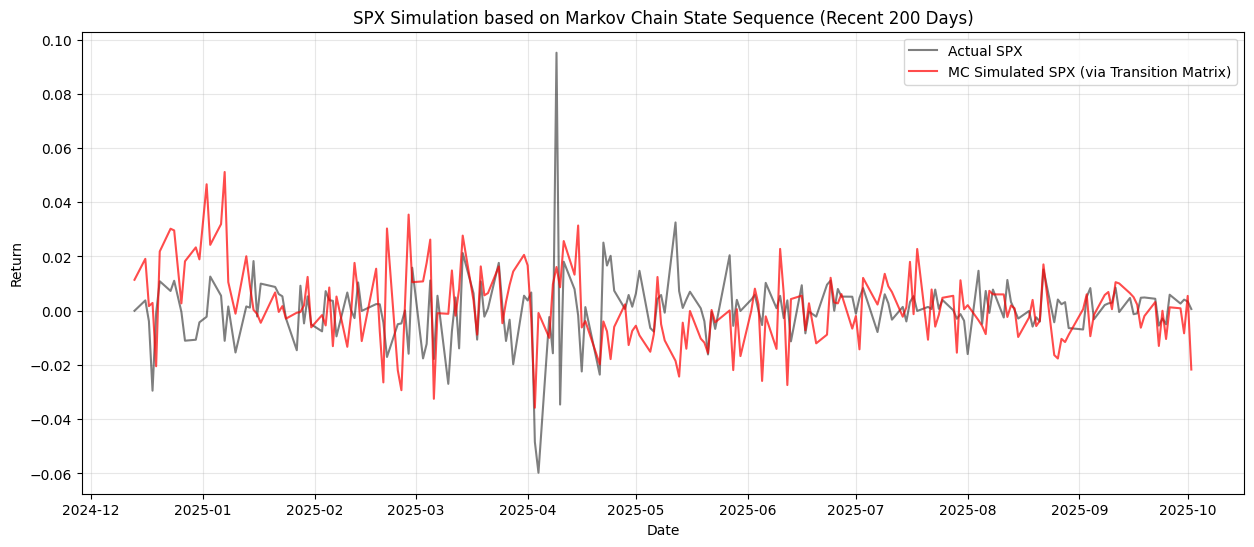

In [24]:
# 1. 状態遷移数列（マルコフ連鎖）の生成
n_steps = len(df_features)
simulated_regimes = np.zeros(n_steps, dtype=int)

# 初期状態は、実データの最初の時点のレジームとします
simulated_regimes[0] = df_features['Regime'].iloc[0]

# 再現性のための乱数シード設定
np.random.seed(47)

for t in range(1, n_steps):
    prev_state = simulated_regimes[t-1]
    # 直前の状態の遷移確率ベクトルに従って、次の状態を確率的にサンプリング
    simulated_regimes[t] = np.random.choice(N_REGIMES, p=transition_matrix[prev_state])

# 2. 各レジームのVARMAXモデルの予測期待値をあらかじめ取得
regime_preds = {}
for i in range(N_REGIMES):
    if i in models_varmax:
        regime_preds[i] = models_varmax[i].predict()

# 3. 生成された状態系列に基づくシミュレーションの実行
sp500_pred_sim = np.zeros(n_steps)
DGS10_pred_sim = np.zeros(n_steps)
shocks_sp = np.zeros(n_steps)
shocks_dgs = np.zeros(n_steps)

for t in range(n_steps):
    sim_regime = simulated_regimes[t]
    
    # シミュレーションされたレジームに対応する予測期待値を取得
    sp500_pred_sim[t] = regime_preds[sim_regime]['sp500'].iloc[t]
    DGS10_pred_sim[t] = regime_preds[sim_regime]['DGS10'].iloc[t]
    
    # シミュレーションされたレジームに対応する共分散行列からショックをサンプリング
    cov_matrix = regime_cov_matrices[sim_regime]
    shock = np.random.multivariate_normal([0, 0], cov_matrix)
    shocks_sp[t] = shock[0]
    shocks_dgs[t] = shock[1]

# 4. シミュレーション結果をDataFrameに追加（MC: Monte Carloの略）
df_features['Regime_simulated_mc'] = simulated_regimes
df_features['sp500_simulated_mc'] = sp500_pred_sim + shocks_sp
df_features['DGS10_simulated_mc'] = DGS10_pred_sim + shocks_dgs

print("状態遷移確率行列に基づくシミュレーションデータの生成が完了しました！")

# 5. シミュレーション結果のプロット（直近200日間）
plt.figure(figsize=(15, 6))
plt.plot(df_features.index[-200:], df_features['sp500'].iloc[-200:], label='Actual SPX', color='black', alpha=0.5)
plt.plot(df_features.index[-200:], df_features['sp500_simulated_mc'].iloc[-200:], label='MC Simulated SPX (via Transition Matrix)', color='red', alpha=0.7)
plt.title('SPX Simulation based on Markov Chain State Sequence (Recent 200 Days)')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


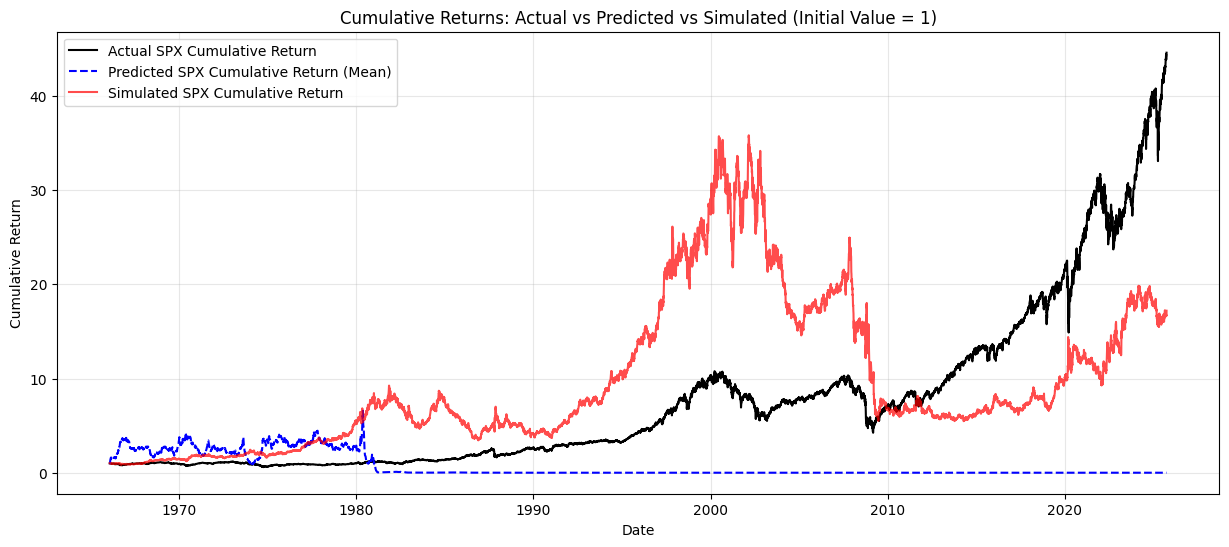

In [26]:
# 欠損値（NaN）を0で埋めてから累積積（cumprod）を計算
df_features['cum_sp500'] = (1 + df_features['sp500'].fillna(0)).cumprod()
df_features['cum_sp500_pred'] = (1 + df_features['sp500_simulated_mc'].fillna(0)).cumprod()
df_features['cum_sp500_sim'] = (1 + df_features['sp500_simulated'].fillna(0)).cumprod()

plt.figure(figsize=(15, 6))
plt.plot(df_features.index, df_features['cum_sp500'], label='Actual SPX Cumulative Return', color='black')
plt.plot(df_features.index, df_features['cum_sp500_pred'], label='Predicted SPX Cumulative Return (Mean)', color='blue', linestyle='--')
plt.plot(df_features.index, df_features['cum_sp500_sim'], label='Simulated SPX Cumulative Return', color='red', alpha=0.7)
plt.title('Cumulative Returns: Actual vs Predicted vs Simulated (Initial Value = 1)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
